<a href="https://colab.research.google.com/github/Shankar-Savalgi/Shankar2007-coder/blob/main/Decision_Tree_Handson06_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/heart (1).csv')

In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
# EDA- Exploratory Data Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
#Check in the target column how many people are haviing a heart disease  and how many people are not having the heart disease?
df['target'].value_counts()
#1 means yes heart disaese- 165 patients are having a Heart Disease
#0 means No- 138 patients are not having a Heart Disease.

,count
target,
1,165
0,138


In [ ]:
# Data Cleaning:

'''
1. Check for the Null Values

2. Check For the Duplicate Values

3. Check for the Outliers

'''

'\n1. Check for the Null Values\n\n2. Check For the Duplicate Values\n\n3. Check for the Outliers\n\n'

In [ ]:
#1. Check for the Null Values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#df.dropna(inplace=True)

In [ ]:
#2. Check For the Duplicate Values
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

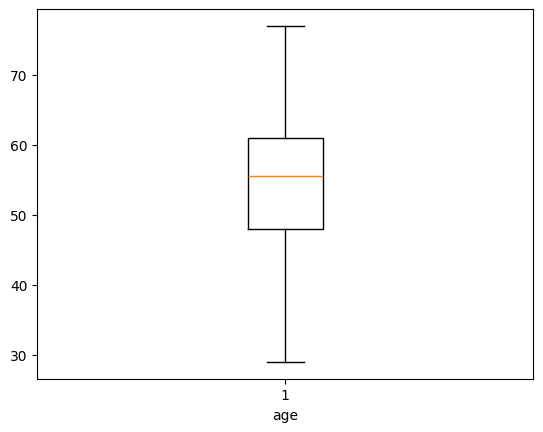

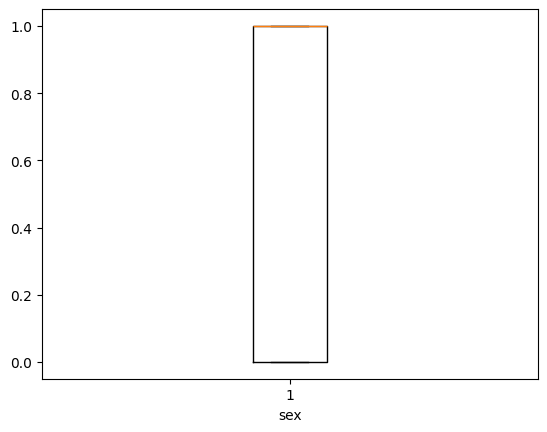

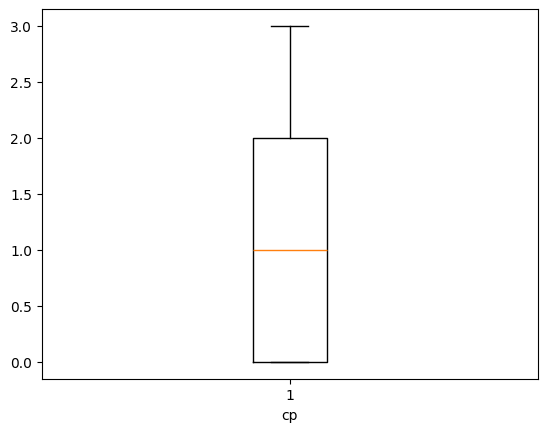

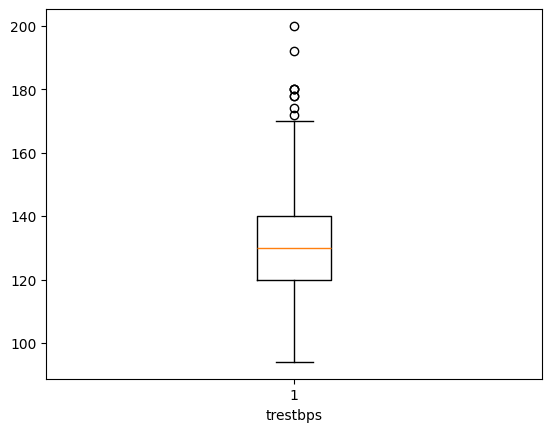

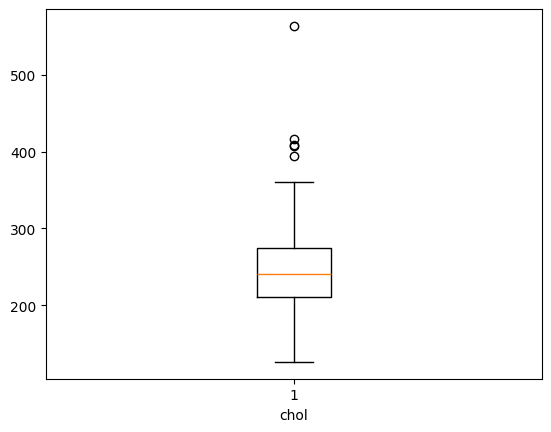

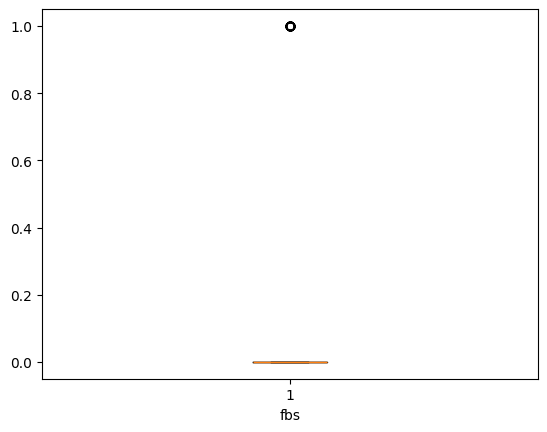

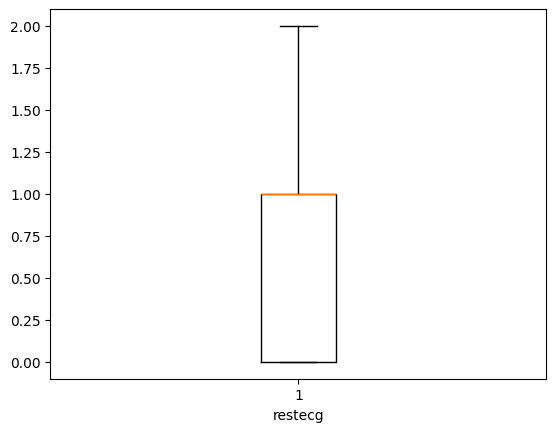

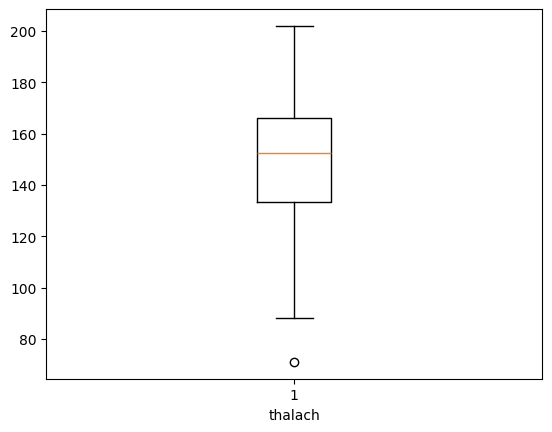

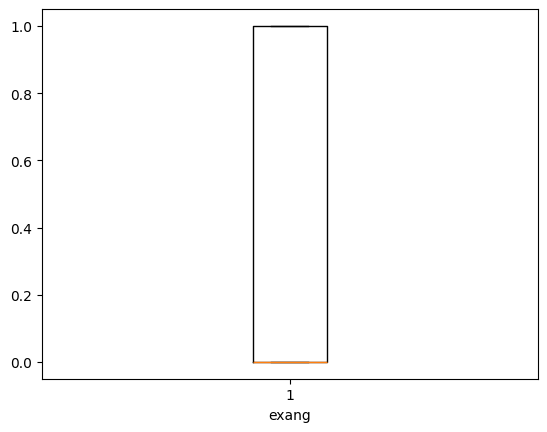

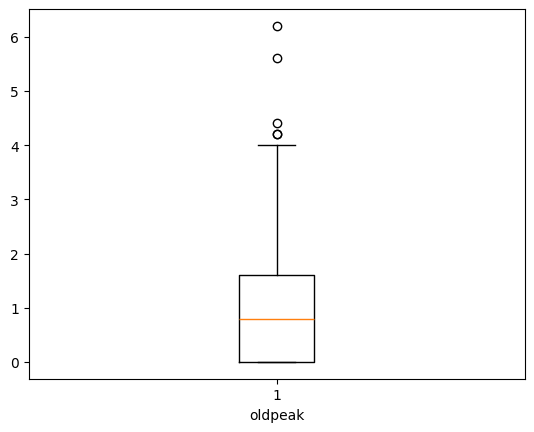

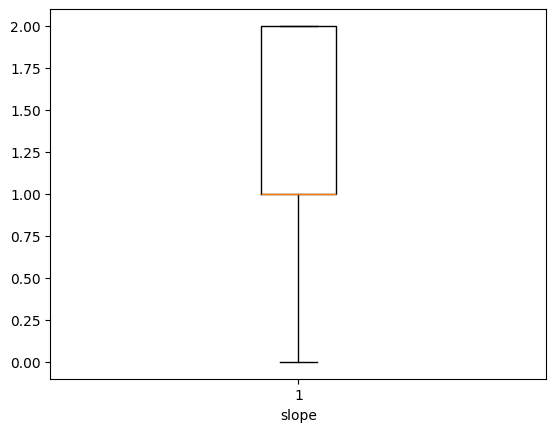

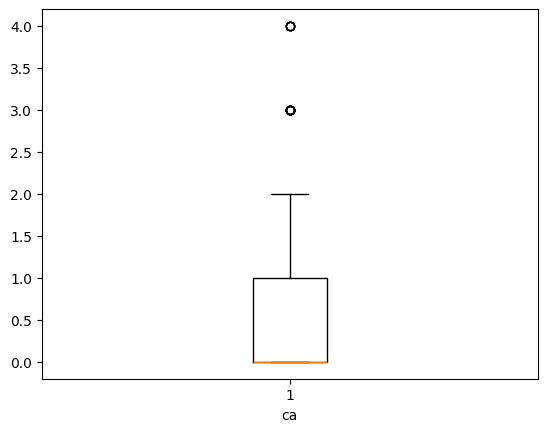

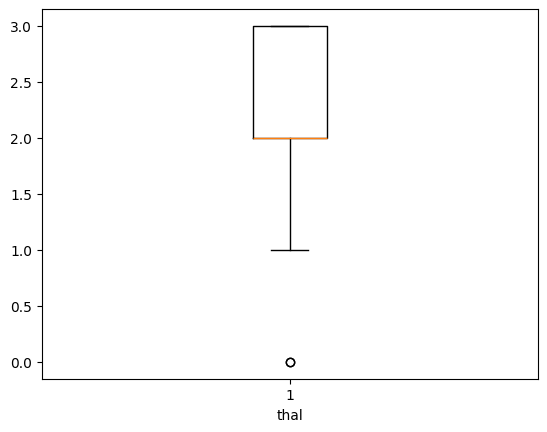

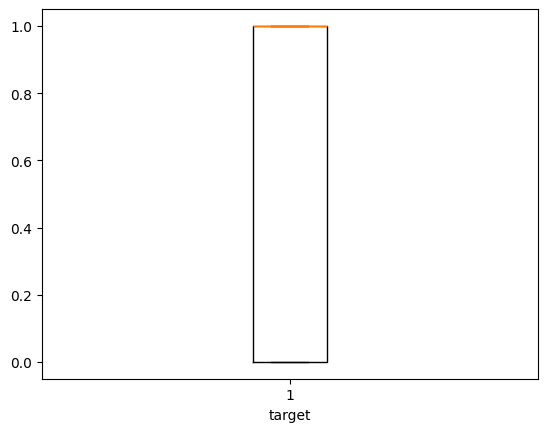

In [ ]:
#3. Check for the Outliers
for i in df.columns:
  if df[i].dtype!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

As the dataset is a real patients information so i am not going to remove the outlier in that case.

And

As tree algorithm dont have much impact of outliers then i can skip the outlier removaal part.

# **Model Building**

In [ ]:
# Divide the data  into independent and depenedent variable
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
x    #Independent Varibale

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [ ]:
y   #Dependent Variable

,target
0,1
1,1
2,1
3,1
4,1
...,...
298,0
299,0
300,0
301,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [ ]:
x_train   #Training Quesstion

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3
197,67,1,0,125,254,1,1,163,0,0.2,1,2,3
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
177,64,1,2,140,335,0,1,158,0,0.0,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,41,1,0,110,172,0,0,158,0,0.0,2,0,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
271,61,1,3,134,234,0,1,145,0,2.6,1,2,2


In [ ]:
y_test   #Training answers

,target
180,0
229,0
111,1
247,0
60,1
...,...
250,0
104,1
300,0
194,0


In [ ]:
x_test   #Testing Question

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,55,1,0,132,353,0,1,132,1,1.2,1,1,3
229,64,1,2,125,309,0,1,131,1,1.8,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
247,66,1,1,160,246,0,1,120,1,0.0,1,3,1
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,51,1,0,140,298,0,1,122,1,4.2,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
194,60,1,2,140,185,0,0,155,0,3.0,1,0,2


In [ ]:
y_test #Testing Answers

,target
180,0
229,0
111,1
247,0
60,1
...,...
250,0
104,1
300,0
194,0


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier()

In [ ]:
# Train the Model
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
#Test the model
y_pred=dt.predict(x_test)

In [ ]:
new_df=pd.DataFrame()
new_df['Actual Value']=y_test
new_df['Predicted Value']=y_pred
new_df

,Actual Value,Predicted Value
180,0,0
229,0,0
111,1,1
247,0,1
60,1,1
...,...,...
250,0,0
104,1,1
300,0,0
194,0,0


In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test,y_pred)

0.7704918032786885

In [ ]:
confusion_matrix(y_test,y_pred)

array([[25,  4],
       [10, 22]])

In [ ]:
from sklearn import tree

[Text(0.5663265306122449, 0.9545454545454546, 'x[12] <= 2.5\ngini = 0.495\nsamples = 241\nvalue = [109, 132]'),
 Text(0.32142857142857145, 0.8636363636363636, 'x[11] <= 0.5\ngini = 0.382\nsamples = 148\nvalue = [38, 110]'),
 Text(0.44387755102040816, 0.9090909090909092, 'True  '),
 Text(0.20408163265306123, 0.7727272727272727, 'x[9] <= 1.7\ngini = 0.208\nsamples = 102\nvalue = [12, 90]'),
 Text(0.12244897959183673, 0.6818181818181818, 'x[0] <= 58.5\ngini = 0.139\nsamples = 93\nvalue = [7, 86]'),
 Text(0.061224489795918366, 0.5909090909090909, 'x[3] <= 109.0\ngini = 0.028\nsamples = 71\nvalue = [1, 70]'),
 Text(0.04081632653061224, 0.5, 'x[1] <= 0.5\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.02040816326530612, 0.4090909090909091, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.061224489795918366, 0.4090909090909091, 'x[8] <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.04081632653061224, 0.3181818181818182, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.08

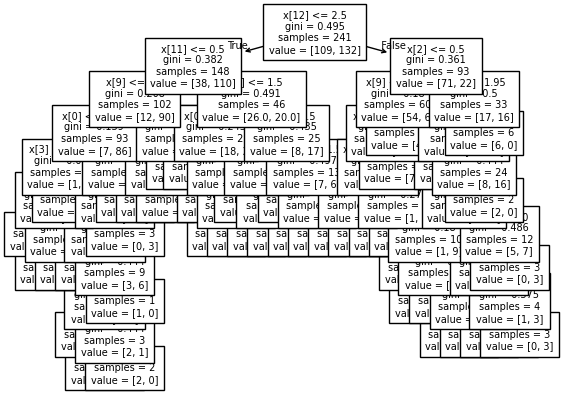

In [ ]:
tree.plot_tree(dt,fontsize=7)

In [ ]:
dt.get_depth()

10

# Max_Depth:

Max Depth is a hyperparameter used in decision tree. It controls how deep the tree can split the data.


In [ ]:
depths=[1,2,3,4,5,6,7,8,9,10,11,12,13]
for i in depths:
  dt=DecisionTreeClassifier(max_depth=i,random_state=42)
  dt.fit(x_train,y_train)
  y_pred=dt.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(f'Max_depth is {i} Accuracy Score is {acc}')

Max_depth is 1 Accuracy Score is 0.7213114754098361
Max_depth is 2 Accuracy Score is 0.7377049180327869
Max_depth is 3 Accuracy Score is 0.7868852459016393
Max_depth is 4 Accuracy Score is 0.8032786885245902
Max_depth is 5 Accuracy Score is 0.8032786885245902
Max_depth is 6 Accuracy Score is 0.7704918032786885
Max_depth is 7 Accuracy Score is 0.7704918032786885
Max_depth is 8 Accuracy Score is 0.7868852459016393
Max_depth is 9 Accuracy Score is 0.7704918032786885
Max_depth is 10 Accuracy Score is 0.7868852459016393
Max_depth is 11 Accuracy Score is 0.7704918032786885
Max_depth is 12 Accuracy Score is 0.7704918032786885
Max_depth is 13 Accuracy Score is 0.7704918032786885
